### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [34]:
data = pd.read_csv('data/coupons.csv')

In [35]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [36]:
# Below we display the information of the data set to assess necessary data clean up. 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

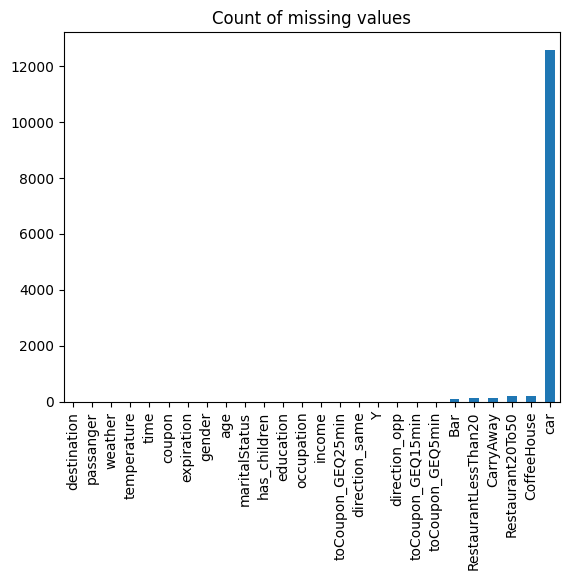

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

In [37]:
# Checking for null values
data.isnull().sum().sort_values().plot(kind = 'bar')
plt.savefig('images/data_missing_values_count_plot.png')
plt.title("Count of missing values")
plt.show()
data.isnull().sum()
# Notably there are a lot of missing values for Car, and few other missing values for 
# Bar, RestaurantLessThan20, CarryAway, Restaurant20To50 and CoffeeHouse.

# Let's explore these columns with missing values

3. Decide what to do about your missing data -- drop, replace, other...

In [38]:
#car
car_unique_values = data.loc[:,'car'].unique()
car_missing_value_count = data['car'].isnull().sum()

print("'Car' column analysis")
print(f"Unique values for the column: {car_unique_values}")
print(f"Number of missing values: {car_missing_value_count} of 12684 entries")
print("""Next steps: 
- Drop column, too many missing values""")

'Car' column analysis
Unique values for the column: [nan 'Scooter and motorcycle' 'crossover' 'Mazda5' 'do not drive'
 'Car that is too old to install Onstar :D']
Number of missing values: 12576 of 12684 entries
Next steps: 
- Drop column, too many missing values


In [39]:
#CoffeeHouse 
coffeehouse_missing_values = data.loc[:,'CoffeeHouse'].unique()
coffeehouse_missing_value_count = data['CoffeeHouse'].isnull().sum()

print("'CoffeeHouse' column analysis")
print(f"Unique values for the column: {coffeehouse_missing_values}")
print(f"Number of missing values: {coffeehouse_missing_value_count} of 12684 entries")
print("""Next steps:
- Replace missing values with mode""")

'CoffeeHouse' column analysis
Unique values for the column: ['never' 'less1' '4~8' '1~3' 'gt8' nan]
Number of missing values: 217 of 12684 entries
Next steps:
- Replace missing values with mode


In [40]:
#Restaurant20To50
restaurant20To50_missing_values = data.loc[:,'Restaurant20To50'].unique()
restaurant20To50_missing_value_count = data['Restaurant20To50'].isnull().sum()

print("'Restaurant20To50' column analysis")
print(f"Unique values for the column: {restaurant20To50_missing_values}")
print(f"Number of missing values: {restaurant20To50_missing_value_count} of 12684 entries")
print("""Next steps:
- Replace missing values with mode""")

'Restaurant20To50' column analysis
Unique values for the column: ['1~3' 'less1' 'never' 'gt8' '4~8' nan]
Number of missing values: 189 of 12684 entries
Next steps:
- Replace missing values with mode


In [41]:
#CarryAway
carryaway_missing_values = data.loc[:,'CarryAway'].unique()
carryaway_missing_value_count = data['CarryAway'].isnull().sum()

print("'CarryAway' column analysis")
print(f"Unique values for the column: {carryaway_missing_values}")
print(f"Number of missing values: {carryaway_missing_value_count} of 12684 entries")
print("""Next steps:
- Replace missing values with mode""")


'CarryAway' column analysis
Unique values for the column: [nan '4~8' '1~3' 'gt8' 'less1' 'never']
Number of missing values: 151 of 12684 entries
Next steps:
- Replace missing values with mode


In [42]:
#RestaurantLessThan20
restaurantlessthan20_missing_values = data.loc[:,'RestaurantLessThan20'].unique()
restaurantlessthan20_missing_value_count = data['RestaurantLessThan20'].isnull().sum()

print("'RestaurantLessThan20' column analysis")
print(f"Unique values for the column: {restaurantlessthan20_missing_values}")
print(f"Number of missing values: {restaurantlessthan20_missing_value_count} of 12684 entries")
print("""Next steps:
- Replace missing values with mode""")

'RestaurantLessThan20' column analysis
Unique values for the column: ['4~8' '1~3' 'less1' 'gt8' nan 'never']
Number of missing values: 130 of 12684 entries
Next steps:
- Replace missing values with mode


In [43]:
#Bar
bar_missing_values = data.loc[:,'Bar'].unique()
bar_missing_value_count = data['Bar'].isnull().sum()

print("'Bar' column analysis")
print(f"Unique values for the column: {bar_missing_values}")
print(f"Number of missing values: {bar_missing_value_count} of 12684 entries")

# Key Findings: The column contains boolean values, few values are missing
# Recommendation: Replace with Average
print("""Next steps: 
- Replace missing values with mode""")

'Bar' column analysis
Unique values for the column: ['never' 'less1' '1~3' 'gt8' nan '4~8']
Number of missing values: 107 of 12684 entries
Next steps: 
- Replace missing values with mode


In [44]:
# Executing recommendations for each column missing values

#Car: Drop column
clean_data = data.drop(columns=['car'])
#For columns CoffeeHouse, Restaurant20To50, CarryAway, RestaurantLessThan20 and Bar
# -> Replace missing values with mode of the column.
columns = ['CoffeeHouse', 'Restaurant20To50', 'CarryAway', 'RestaurantLessThan20', 'Bar']
for c in columns:
    clean_data[c] = clean_data[c].fillna(clean_data[c].mode()[0])

clean_data.isnull().sum()



destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

4. What proportion of the total observations chose to accept the coupon?



In [45]:
# The mean (average) of column 'Y' represents the proportion of coupons being accepted
accepted_coupons =  clean_data['Y'].mean()
print(f"The acceptance ratio of the cupon was {accepted_coupons}")

The acceptance ratio of the cupon was 0.5684326710816777


5. Use a bar plot to visualize the `coupon` column.

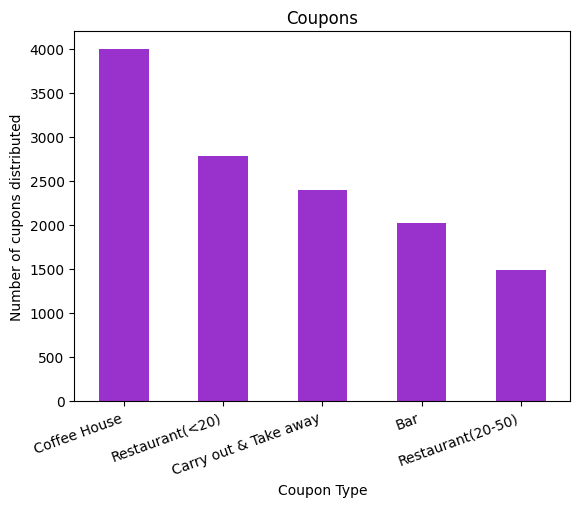

<Figure size 640x480 with 0 Axes>

In [46]:
#Creating a bar plot to visualize coupon data using Matplotlib
clean_data['coupon'].value_counts().plot(kind='bar', color='darkorchid')
plt.xlabel("Coupon Type")
plt.ylabel("Number of cupons distributed")
plt.title("Coupons")
plt.xticks(rotation=20, ha='right')
plt.show()
plt.savefig('images/coupon_distribution_bar_plot.png')

6. Use a histogram to visualize the temperature column.

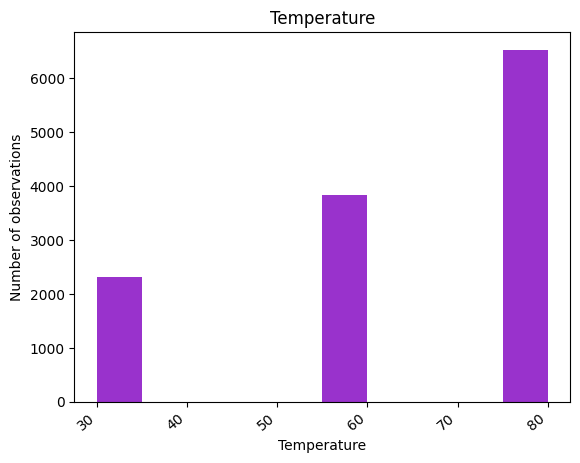

<Figure size 640x480 with 0 Axes>

In [47]:
clean_data['temperature'].plot(kind='hist', color='darkorchid')
plt.xlabel("Temperature")
plt.ylabel("Number of observations")
plt.title("Temperature")
plt.xticks(rotation=40, ha='right')
plt.show()
plt.savefig('images/temperature_histogram.png')

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [48]:
# Using the query function on the DataFrame to pull only rows for Bar coupons.
bar_data = clean_data.query("coupon == 'Bar'")

bar_data

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12663,No Urgent Place,Friend(s),Sunny,80,10PM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12664,No Urgent Place,Friend(s),Sunny,55,10PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12667,No Urgent Place,Alone,Rainy,55,10AM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12670,No Urgent Place,Partner,Rainy,55,6PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0


2. What proportion of bar coupons were accepted?


In [49]:
# The mean (average) of column 'Y' represents the proportion of coupons being accepted. Since the bar_data DataFrame
# only contains Bar coupons, we will get the acceptance ratio of bar coupons. 

bar_coupon_acceptance = bar_data['Y'].mean()
print(f"The acceptance ratio of bar coupons is {bar_coupon_acceptance}")

The acceptance ratio of bar coupons is 0.41001487357461575


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [50]:
# We can consider an observation belongs to the group of 3 or less times for those observations that the column 'Bar' 
# contains any of the following values: ['never' 'less1' '1~3']. The observation will belong to the often group if the 
# same column contains any of the following values: ['gt8' nan '4~8']

bar_3_or_less = ['never', 'less1', '1~3']
bar_more_often = ['gt8', '4~8']

# We then calculate the mean for each subgroup
non_frequent_bar = bar_data.query("Bar in @bar_3_or_less")['Y'].mean() 
frequent_bar = bar_data.query("Bar in @bar_more_often")['Y'].mean() 

print(f"The acceptance rate of those that visited a bar 3 or fewer times a month was {non_frequent_bar}")
print(f"The acceptance rate of those that visited more often than 3 times a month was {frequent_bar}")

if frequent_bar > non_frequent_bar:
    print(f"People that visit bars often (i.e. more than 3 times) are {(frequent_bar - non_frequent_bar)*100}% more likely to accept the Bar coupon")
elif frequent_bar < non_frequent_bar:
    print(f"People that visit bars often (i.e. more than 3 times) are {(non_frequent_bar - frequent_bar)*100}% less likely to accept the Bar coupon")
else:
    print(f"The acceptance rate is the same for both frequent and not frequent bar visitors")

The acceptance rate of those that visited a bar 3 or fewer times a month was 0.37073707370737075
The acceptance rate of those that visited more often than 3 times a month was 0.7688442211055276
People that visit bars often (i.e. more than 3 times) are 39.81071473981569% more likely to accept the Bar coupon


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [51]:
# We can consider someone visits a Bar more than once a month if the 'Bar'column contains any of the following values: ['1~3','gt8','4~8']
more_than_once_a_month_bar = ['1~3','gt8','4~8']

#over_25_yo:
# The Age column type is object, which means there is a mix of numeric and text values.
# Using the unique() function, we will retrieve the age categories and validate if they are good for our analysis
bar_data['age'].unique()
# As per the output, we can use the existing categories to differentiate users. To use numeric logic opperators, we will convert text
# values to numeric and then update the series type to int. Note that we are assigning 20 for under 21 and 50 for over 50.
bar_data.loc[:,'age'] = bar_data['age'].str.replace('below21', '20')
bar_data.loc[:,'age'] = bar_data['age'].str.replace('50plus', '50')
bar_data.loc[:,'age'] = bar_data['age'].astype('int64')

# Having updated the Age column to numeric values, we may proceed with the analysis

age25_and_barhopping = bar_data.query("age > 25 and Bar in @more_than_once_a_month_bar")['Y'].mean()
everyone_barhopping = bar_data['Y'].mean()
print(f"The acceptance ratio of those over 25 years old who visit a bar once a month or more is {age25_and_barhopping}")
print(f"The acceptance ratio of everyone regardless how often they visit a bar is {everyone_barhopping}")

if age25_and_barhopping > everyone_barhopping:
    print(f"The acceptance ratio of those over 25 years old who visit a bar once a month or more is higher than everyones by {(age25_and_barhopping - everyone_barhopping)*100}%")
elif age25_and_bar_hopping < everyone_barhopping:
    print(f"The acceptance ratio of those over 25 years old who visit a bar once a month or more is lower than everyones by {(everyone_barhopping - age25_and_bar_hopping)*100}%")
else:
    print("The acceptance ratio is the same for both groups")

The acceptance ratio of those over 25 years old who visit a bar once a month or more is 0.6952380952380952
The acceptance ratio of everyone regardless how often they visit a bar is 0.41001487357461575
The acceptance ratio of those over 25 years old who visit a bar once a month or more is higher than everyones by 28.522322166347948%


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [52]:
# We use unique to find the exact value to find those that do farming, fishing or forestry
bar_data['occupation'].unique()

array(['Unemployed', 'Architecture & Engineering', 'Student',
       'Education&Training&Library', 'Healthcare Support',
       'Healthcare Practitioners & Technical', 'Sales & Related',
       'Management', 'Arts Design Entertainment Sports & Media',
       'Computer & Mathematical', 'Life Physical Social Science',
       'Personal Care & Service', 'Community & Social Services',
       'Office & Administrative Support', 'Construction & Extraction',
       'Legal', 'Retired', 'Installation Maintenance & Repair',
       'Transportation & Material Moving', 'Business & Financial',
       'Protective Service', 'Food Preparation & Serving Related',
       'Production Occupations',
       'Building & Grounds Cleaning & Maintenance',
       'Farming Fishing & Forestry'], dtype=object)

In [53]:
# Analysis group components
more_than_once_a_month_bar = ['1~3','gt8','4~8']

group_drivers = bar_data[
    (bar_data['Bar'].isin(more_than_once_a_month_bar)) & 
    (bar_data['occupation'] != 'Farming Fishing & Forestry') &
    (bar_data['passanger'] != 'Kid(s)')
]

#Calculation of the coupon acceptance ratio of each group
group_acceptance_ratio = group_drivers['Y'].mean()
everyone_barhopping = bar_data['Y'].mean()

print("""The target group is defined as those drivers that:
- visit a bar at least once a month,
- are not involved in Farming, Fishing or Forestry and
- are not accompanied by a children.""")
print(f'Target group acceptance ratio: {group_acceptance_ratio}')
print(f'Everyone acceptance ratio: {everyone_barhopping}')

if group_acceptance_ratio > everyone_barhopping:
    print(f"The target group is more likely to accept the coupon than everyone by {(group_acceptance_ratio - everyone_barhopping)*100}%")
elif group_acceptance_ratio < everyone_barhopping:
    print(f"The target group is less likely to accept the coupon than everyone by {(everyone_barhopping - group_acceptance_ratio)*100}%")
else:
    print("The target group as likely to accept the coupon as everyone else")


The target group is defined as those drivers that:
- visit a bar at least once a month,
- are not involved in Farming, Fishing or Forestry and
- are not accompanied by a children.
Target group acceptance ratio: 0.7132486388384754
Everyone acceptance ratio: 0.41001487357461575
The target group is more likely to accept the coupon than everyone by 30.32337652638597%


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [54]:
# Checking list of income segments for further analysis
bar_data['income'].unique()

array(['$37500 - $49999', '$62500 - $74999', '$12500 - $24999',
       '$75000 - $87499', '$50000 - $62499', '$25000 - $37499',
       '$100000 or More', '$87500 - $99999', 'Less than $12500'],
      dtype=object)

In [55]:
# Group 1: go to bars more than once a month, had passengers that were not a kid, and were not widowed
more_than_once_a_month_bar = ['1~3','gt8','4~8']
income_less_50k = ['$37500 - $49999', '$12500 - $24999', '$25000 - $37499', 'Less than $12500']

group_1 = bar_data[
    (bar_data['Bar'].isin(more_than_once_a_month_bar)) & 
    (bar_data['passanger'] != 'Kid(s)') &
    (bar_data['maritalStatus'] != 'Widowed')
]

# Group 2: go to bars more than once a month and are under the age of 30
group_2 = bar_data[
    (bar_data['Bar'].isin(more_than_once_a_month_bar)) & 
    (bar_data['age'] < 30) 
]

# Group 3: go to cheap restaurants more than 4 times a month and income is less than 50K
group_3 = bar_data[
    (bar_data['RestaurantLessThan20'].isin(['4~8','gt8'])) & 
    (bar_data['income'].isin(income_less_50k))
]

# Calculate acceptance ratio for each group:
group1_ratio = group_1['Y'].mean()
group2_ratio = group_2['Y'].mean()
group3_ratio = group_3['Y'].mean()

#Print ratios
multiline_f_string = f"""Acceptance ratio per group:
- Group 1: go to bars more than once a month, had passengers that were not a kid, and were not widowed: {group1_ratio}
- Group 2: go to bars more than once a month and are under the age of 30: {group2_ratio}
- Group 3: go to cheap restaurants more than 4 times a month and income is less than 50K: {group3_ratio}"""
print(multiline_f_string)

Acceptance ratio per group:
- Group 1: go to bars more than once a month, had passengers that were not a kid, and were not widowed: 0.7132486388384754
- Group 2: go to bars more than once a month and are under the age of 30: 0.7217391304347827
- Group 3: go to cheap restaurants more than 4 times a month and income is less than 50K: 0.45348837209302323


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [56]:
print("""
Hypotesis: 
Those who frequent bars often are more likely to accept coupons to go to a bar.
The oposit may also be true: Those that accepted the bar coupon likely often visit bars.
""")


Hypotesis: 
Those who frequent bars often are more likely to accept coupons to go to a bar.
The oposit may also be true: Those that accepted the bar coupon likely often visit bars.



### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [57]:
# Coffee House analysis 
# Create data set for analysis
coffee_data = clean_data.query("coupon == 'Coffee House'")
coffee_data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,0,0,0,1,0
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12,No Urgent Place,Kid(s),Sunny,55,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,1
15,Home,Alone,Sunny,80,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,0,0,0,1,0


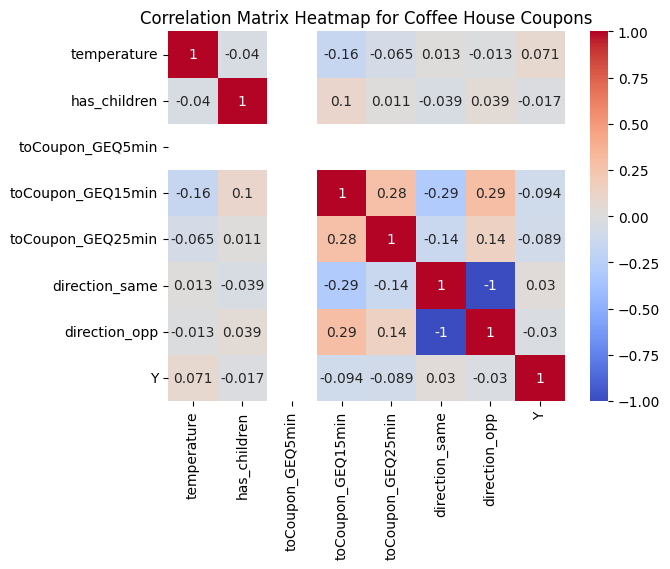

<Figure size 640x480 with 0 Axes>

In [58]:
coffee_corr_matrix = coffee_data.corr(numeric_only=True)
sns.heatmap(coffee_corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title("Correlation Matrix Heatmap for Coffee House Coupons")
plt.show()
plt.savefig('images/coffee_corr_matrix.png')

##Given the provided correlation matrix, one can infer that:
# 1. The direction to the Coffee House, has the same correlation but with different signs, meaning that the direction has the same 
# weigth in the decision but depending if it's the same or oposite direction, the relationship will be positive or negative. 
# 2. We can also notice that the distance to the coupon has the biggest impact in the decision of accepting or rejecting the coupon. 

In [59]:
#Define baseline for analysis
everyone_coffee_acceptance = coffee_data['Y'].mean()
print(f"The baseline acceptance rate for those who were offered a Coffee House cupon is {everyone_coffee_acceptance}")

The baseline acceptance rate for those who were offered a Coffee House cupon is 0.49924924924924924


In [60]:
# Acceptance ratio for those that the Coffee House depending of the direction they were headed to vs those
# the coffe house was in the opposite direction
on_the_way_acceptance = coffee_data.query('direction_same == 1')['Y'].mean()
opposite_direction_acceptance = coffee_data.query('direction_opp == 1')['Y'].mean()

difference = (on_the_way_acceptance - opposite_direction_acceptance)*100

ans_fstring= f"""Acceptance ratio per depending if the Coffee House was on the way or in the opposite direction:
- Same direction acceptance ratio: {on_the_way_acceptance}.
- Opposite direction acceptance ratio: {opposite_direction_acceptance}"""

print(ans_fstring)

Acceptance ratio per depending if the Coffee House was on the way or in the opposite direction:
- Same direction acceptance ratio: 0.5306666666666666.
- Opposite direction acceptance ratio: 0.49199014171287736


In [61]:
# Age group analysis
age_groups = coffee_data.groupby('age')['Y'].mean()
age_groups

age
21         0.524349
26         0.514828
31         0.476726
36         0.467662
41         0.501538
46         0.513636
50plus     0.420183
below21    0.696774
Name: Y, dtype: float64

In [62]:
# Time of the day 
time_of_the_day = coffee_data.groupby('time')['Y'].mean().sort_values(ascending=False)
time_of_the_day

time
10AM    0.640712
2PM     0.547859
7AM     0.445783
10PM    0.424242
6PM     0.412626
Name: Y, dtype: float64

In [63]:
age_groups.sort_values(ascending= False).iloc[0]

np.float64(0.6967741935483871)

In [64]:
# Summary of learnings from Coffee House analysis

print("""
Hypotesis:
1. Coffee is most times consumed during mornings, thus, it is likely the coupons will be accepted more often in mornings than during the evening.
2. Minors are more likely to consume coffee in a Coffee House.
3. People is more likely to accept the coupon if the Coffee House is on their way.
Outcome of analysis:
""")
print(f"Findings 1: The most popular time to accept the coffee coupon was {time_of_the_day.index[0]}")
print(f"Findings 2: The age group of {age_groups.sort_values(ascending= False).index[0]} was the most prone to accept the coupon with a {age_groups.sort_values(ascending= False).iloc[0]} acceptance ratio.")
print("Findings 3: There is a higher chance the user accepts the coupon if the Coffee House is in the same direction they were headed to:")
print(f"The acceptance ratio when the Coffee House is on the way is higher than when it's in the opposite direction by {difference}%")
      


Hypotesis:
1. Coffee is most times consumed during mornings, thus, it is likely the coupons will be accepted more often in mornings than during the evening.
2. Minors are more likely to consume coffee in a Coffee House.
3. People is more likely to accept the coupon if the Coffee House is on their way.
Outcome of analysis:

Findings 1: The most popular time to accept the coffee coupon was 10AM
Findings 2: The age group of below21 was the most prone to accept the coupon with a 0.6967741935483871 acceptance ratio.
Findings 3: There is a higher chance the user accepts the coupon if the Coffee House is in the same direction they were headed to:
The acceptance ratio when the Coffee House is on the way is higher than when it's in the opposite direction by 3.867652495378926%
